# El multiplicador de impuestos, de tres maneras

**¿Qué le pasa al PIB de EE.UU. tras un aumento legislado de impuestos de 1%
del PIB?** Las tres respuestas canónicas de la literatura difieren por un
factor de tres: alrededor de **−1** (Blanchard-Perotti 2002 QJE), alrededor
de **−3** (Romer-Romer 2010 AER), y algo intermedio cuando la información
narrativa se usa como *instrumento* (Mertens-Ravn 2013 AER, 2014 JME). El
mismo país, las mismas cuentas nacionales. Este notebook ejecuta las tres
filosofías de identificación sobre **un único conjunto de datos trimestral
congelado** — de modo que cada diferencia que veas es identificación, no
datos.

## Las tres identificaciones en matemáticas

Las tres parten del mismo VAR en forma reducida en $x_t = (\tau_t, g_t, y_t)'$
— log de la recaudación federal real, log del gasto federal real, log del PIB real:
$$ x_t = A_1 x_{t-1} + \cdots + A_p x_{t-p} + u_t, \qquad u_t = B\,\varepsilon_t,\quad \Sigma_u = BB'. $$

**(a) Blanchard-Perotti** identifican el choque fiscal con un dato
*institucional*: dentro del trimestre, la recaudación se mueve con el
producto solo a través del código tributario, con elasticidad $\theta = 2.08$
medida a partir de tramos impositivos y calendarios de recaudación, de modo que
$$ u^\tau_t = \theta\,u^y_t + \varepsilon^\tau_t, \qquad u^g_t = \varepsilon^g_t, \qquad u^y_t = b_\tau u^\tau_t + b_g u^g_t + \varepsilon^y_t, $$
y $\varepsilon^\tau_t$ (el residuo fiscal *ajustado por ciclo*) es un instrumento válido para la ecuación de $u^y$.

**(b) Romer-Romer** se saltan el VAR: leen el registro legislativo, conservan
solo los cambios impositivos motivados por el déficit o por objetivos de
largo plazo (no por el ciclo), y ponen esa serie narrativa $z_t$ (en % del
PIB) directamente en una proyección local
$$ y_{t+h} - y_{t-1} = \alpha_h + m(h)\, z_t + \text{rezagos} + e_{t+h}, $$
de modo que $m(h)$ es la senda del multiplicador (LP de Jordà, aumentada con rezagos según Montiel Olea-Plagborg-Møller 2021).

**(c) Mertens-Ravn** usan la misma serie narrativa pero solo como
*instrumento externo* para el residuo fiscal del VAR — relevancia y
exogeneidad,
$$ \mathbb{E}[z_t \varepsilon^\tau_t] = \phi \neq 0, \qquad \mathbb{E}[z_t \varepsilon^{-\tau}_t] = 0 \;\Rightarrow\; B_{\cdot 1} \propto \Sigma_u \Pi, \quad \Pi = \mathbb{E}[u_t z_t]/\mathbb{E}[z_t^2], $$
lo cual es robusto a *errores de medición* en las magnitudes narrativas — siempre que la primera etapa sea fuerte.

**Normalización.** Escalamos cada choque identificado para que los impuestos
suban 1% del PIB en el impacto: $\Delta\tau_0 = (Y/T)\times 1\%$ en puntos
logarítmicos. Entonces la respuesta del log-PIB en por ciento *es* el
multiplicador acumulado dólar por dólar: el cambio en el nivel del PIB en el
horizonte $h$ por dólar inicial de impuestos.

**Intuición.** La correlación en forma reducida entre impuestos y producto
está irremediablemente contaminada: las recesiones recortan la recaudación
automáticamente, y el Congreso legisla en respuesta al ciclo. Cada método
rompe el círculo con un *tipo* distinto de conocimiento. BP aportan un número
externo a la muestra (la elasticidad mecánica del código tributario); RR
aportan lectura de archivo (qué leyes *no* trataban del ciclo); MR aportan un
puente econométrico (las fechas narrativas como instrumento, inmune a
magnitudes mal medidas). Ninguno de los tres estima con más datos que los
otros — *suponen distinto*. Por eso sus respuestas difieren, y por eso el
producto honesto es el menú completo, no un solo número.

## Preparación — un único conjunto de datos congelado

Dos instantáneas viajan con el paquete (se regeneran con
`tools/gen_notebook_data_tax14.py`; se cargan con el ayudante de datos del
paquete `puremacro.replication._data.load_csv`, la misma convención que las
instantáneas de replicación `gali1999` / `kilian2009`):

- `tax14_us_fiscal.csv` — del endpoint fredgraph de FRED, sin clave: `GDPC1`
  (PIB real), `GDP` (PIB nominal), `GDPDEF` (deflactor), `W006RC1Q027SBEA`
  (ingresos tributarios corrientes federales), `FGEXPND` (gasto corriente
  federal), `CPIAUCSL` (IPC, el deflactor alternativo para la curva de
  especificaciones).
- `tax14_narrative_tax_shocks.csv` — las medidas narrativas en % del PIB
  (positivo = aumento de impuestos), congeladas del archivo fiscal público
  del Handbook of Macroeconomics de Valerie Ramey: `rr_exog` (cambios
  exógenos de Romer-Romer), `mtr_u` / `mtr_a` (cambios no anticipados /
  anticipados de Mertens-Ravn). El espejo de GitHub codificado en
  `puremacro.narrative.replication` está muerto, así que los cargadores de
  abajo leen esta instantánea vía `csv_path=`.

Simplificaciones respecto a los artículos, declaradas desde el inicio:
ingresos totales en lugar de los impuestos netos de BP (ingresos menos
transferencias), sin escala per cápita, sin tendencias determinísticas, y
una muestra común 1950T1-2006T4 (el registro narrativo termina a mediados de
los 2000).

In [1]:
import sys
from importlib import resources
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.narrative.replication import load_romer_romer_2010, load_mertens_ravn_2013
from puremacro.var.estimate import estimate_var
from puremacro.var.irf import irf as var_irf
from puremacro.inference.wild_bootstrap import wild_bootstrap_var
from puremacro.inference.weak_iv import olea_pflueger_f
from puremacro.var.identify.proxy import proxy_svar
from puremacro.lp.la_lp import la_lp
from puremacro.inference.spec_curve import enumerate_specs, run_spec_curve

# --- frozen fiscal aggregates (FRED fredgraph snapshot) ----------------------
fiscal = load_csv("tax14_us_fiscal")
fiscal["date"] = pd.to_datetime(fiscal["date"])
fiscal = fiscal.set_index("date")

# --- narrative measures through the package loaders --------------------------
NARR_CSV = str(resources.files("puremacro.replication.data")
               .joinpath("tax14_narrative_tax_shocks.csv"))
rr_inst = load_romer_romer_2010(csv_path=NARR_CSV)               # column rr_exog
mr_u_inst = load_mertens_ravn_2013(csv_path=NARR_CSV, kind="unanticipated")
mr_a_inst = load_mertens_ravn_2013(csv_path=NARR_CSV, kind="anticipated")
print(f"narrative events: RR exogenous = {len(rr_inst.events)}, "
      f"MR unanticipated = {len(mr_u_inst.events)}, "
      f"MR anticipated = {len(mr_a_inst.events)}")
assert len(rr_inst.events) == 45 and len(mr_u_inst.events) == 31

def build_dataset(start="1950-01-01", end="2006-12-31", deflator="gdpdef"):
    """Common sample: logs x100 for the VAR, narrative series as % of GDP."""
    d = fiscal.loc[start:end].copy()
    d["tau"] = 100 * np.log(d["fedtax"] / d[deflator])   # log real federal taxes
    d["g"] = 100 * np.log(d["fedspend"] / d[deflator])   # log real federal spending
    d["y"] = 100 * np.log(d["gdpc1"])                    # log real GDP
    # Narrative instruments: zero in quarters with no legislated change.
    d["rr"] = rr_inst.quarterly.reindex(d.index).fillna(0.0)
    d["mtu"] = mr_u_inst.quarterly.reindex(d.index).fillna(0.0)
    d["mta"] = mr_a_inst.quarterly.reindex(d.index).fillna(0.0)
    return d

d = build_dataset()
tax_share = (d["fedtax"] / d["gdp"]).mean()
SCALE = 1.0 / tax_share       # % change in tax revenue per 1%-of-GDP tax shock
print(f"sample: {d.index[0].date()} .. {d.index[-1].date()}  (T = {len(d)})")
print(f"mean federal tax / GDP = {tax_share:.3f}  ->  a 1%-of-GDP tax increase "
      f"raises revenue by {SCALE:.1f}%")
assert len(d) == 228
assert 0.10 < tax_share < 0.14

P, H = 4, 16                  # VAR lags and IRF horizon (quarters)
hgrid = np.arange(H + 1)

narrative events: RR exogenous = 45, MR unanticipated = 31, MR anticipated = 23
sample: 1950-01-01 .. 2006-10-01  (T = 228)
mean federal tax / GDP = 0.121  ->  a 1%-of-GDP tax increase raises revenue by 8.3%


### El registro narrativo de un vistazo

Ambas series son series de *eventos*: cero salvo en los trimestres en que un
cambio legislado entró en vigor. El signo está en % del PIB, positivo =
aumento de impuestos. Fíjate en lo que la lectura narrativa *excluye*: el
recargo de 1968 — un alza de impuestos de libro de texto — está clasificado
como contracíclico (endógeno) por Romer-Romer, así que está **ausente** de
`rr_exog`. Ese juicio editorial *es* la identificación.

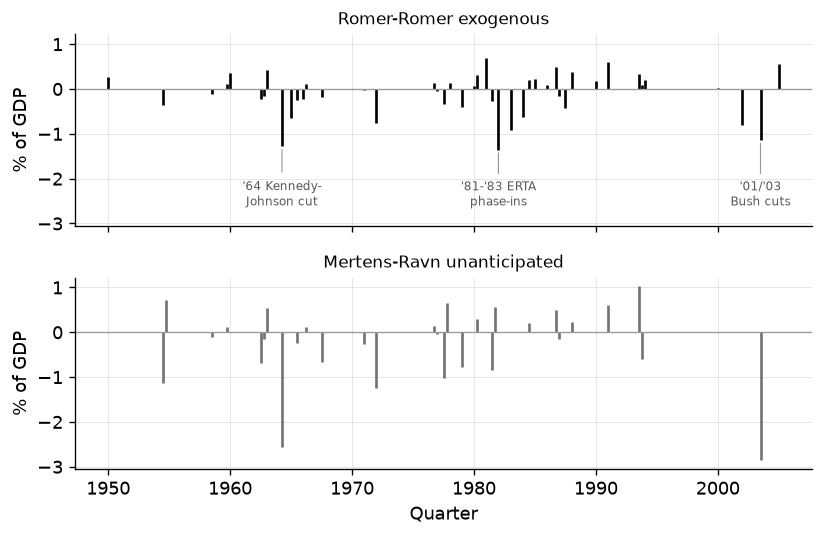

In [2]:
cols = _nbstyle.palette(2)
fig, axes = plt.subplots(2, 1, figsize=(7.0, 4.6), sharex=True, sharey=True)
for ax, col, lbl, c in [(axes[0], "rr", "Romer-Romer exogenous", cols[0]),
                        (axes[1], "mtu", "Mertens-Ravn unanticipated", cols[1])]:
    nz = d[col] != 0
    ax.vlines(d.index[nz], 0, d.loc[nz, col], color=c, linewidth=1.6)
    ax.axhline(0, color="0.6", linewidth=0.8)
    ax.set_ylabel("% of GDP")
    ax.set_title(lbl, fontsize=10)
for ts, txt in [("1964-04-01", "'64 Kennedy-\nJohnson cut"),
                ("1982-01-01", "'81-'83 ERTA\nphase-ins"),
                ("2003-07-01", "'01/'03\nBush cuts")]:
    axes[0].annotate(txt, xy=(pd.Timestamp(ts), d.loc[ts, "rr"]),
                     xytext=(pd.Timestamp(ts), -2.6), fontsize=7, color="0.35",
                     ha="center", arrowprops=dict(arrowstyle="-", color="0.6", lw=0.7))
axes[1].set_xlabel("Quarter")
plt.tight_layout()
plt.show()

## 1. Blanchard-Perotti (2002): la elasticidad institucional

Toda la identificación es un número: $\theta = 2.08$, la elasticidad
intra-trimestral de la recaudación federal al producto implicada por la
estructura de tramos impositivos y los rezagos de recaudación — medida a
partir del código tributario, no estimada en el VAR. Abajo, el álgebra de la
matriz de impacto está escrita en ~15 líneas sobre `estimate_var`: resta la
respuesta automática ($\varepsilon^\tau = u^\tau - \theta u^y$), deja que el
gasto ignore al producto dentro del trimestre, y usa ambos choques
estructurales como instrumentos para la ecuación del producto. Las bandas
salen de reutilizar `wild_bootstrap_var` con esta función de impacto
enchufada.

In [3]:
def make_bp_impact(theta):
    """Blanchard-Perotti (2002 QJE) impact matrix on [tau, g, y] residuals."""
    def bp_impact(A_list, Sigma, resid):
        u_tau, u_g, u_y = resid[:, 0], resid[:, 1], resid[:, 2]
        e_tau = u_tau - theta * u_y            # cyclically-adjusted tax shock
        e_g = u_g                              # spending can't react within quarter
        Z = np.column_stack([e_tau, e_g])      # valid instruments for the y equation
        X = np.column_stack([u_tau, u_g])
        b = np.linalg.solve(Z.T @ X, Z.T @ u_y)   # IV: u_y = b1*u_tau + b2*u_g + e_y
        e_y = u_y - X @ b
        A0 = np.array([[1.0,   0.0,  -theta],     # u_tau - theta*u_y          = e_tau
                       [0.0,   1.0,   0.0],       # u_g                        = e_g
                       [-b[0], -b[1], 1.0]])      # u_y - b1*u_tau - b2*u_g    = e_y
        return np.linalg.inv(A0) * np.array([e_tau.std(), e_g.std(), e_y.std()])
    return bp_impact

THETA_BP = 2.08
Y_var = d[["tau", "g", "y"]].to_numpy()
pt, lo, hi = wild_bootstrap_var(Y_var, p=P, horizon=H,
                                impact_fn=make_bp_impact(THETA_BP),
                                n_boot=200, ci=0.9, seed=0)
pt, lo, hi = [np.transpose(a, (2, 0, 1)) for a in (pt, lo, hi)]   # -> (H+1, n, n)
c_bp = SCALE / pt[0, 0, 0]                 # rescale: tax impact = 1% of GDP
m_bp, m_bp_lo, m_bp_hi = pt[:, 2, 0] * c_bp, lo[:, 2, 0] * c_bp, hi[:, 2, 0] * c_bp
bp_peak = m_bp[:13].min()
print(f"BP multiplier: impact {m_bp[0]:+.2f} | 2yr {m_bp[8]:+.2f} | "
      f"peak {bp_peak:+.2f} at h={int(m_bp[:13].argmin())}")
assert m_bp[0] > -1.0                          # small impact effect...
assert -2.2 < m_bp[8] < -0.6                   # ...builds toward ~ -1
assert -2.6 < bp_peak < -0.9                   # BP's published ballpark

BP multiplier: impact -0.18 | 2yr -1.21 | peak -1.51 at h=12


**Lee el resultado.** El multiplicador de BP arranca cerca de cero y crece
despacio hasta cerca de **−1.2 a los dos años** (pico ≈ −1.5) — el famoso
"casi un dólar por dólar" de Blanchard y Perotti. La respuesta de impacto es
pequeña por construcción: tras purgar el componente automático $\theta u^y$,
lo que queda del residuo fiscal apenas covaría con el producto dentro del
trimestre. Todo descansa en que $\theta$ sea el número externo *correcto* —
guarda esa idea para el ejercicio del final.

## 2. Romer-Romer (2010): la regresión narrativa

RR evitan el VAR: su serie exógena (ya en % del PIB) entra directamente en
una proyección local aumentada con rezagos. Nota que el lado izquierdo de la
LP es la *forma en cambios* $y_{t+h}-y_{t-1}$, de modo que el coeficiente es
la respuesta del **nivel** del PIB en $t+h$ — con nuestras unidades de 1%
del PIB, el multiplicador mismo. Sin ecuación de recaudación, sin
elasticidad: el supuesto de identificación es que la lectura de archivo de
verdad aisló cambios impositivos independientes del ciclo.

In [4]:
H_LP = 20      # LP horizons; lag augmentation p_aug = 4 + 20 (PMW 2021 default)
lp_rr = la_lp(d, y="y", x="rr", horizons=range(0, H_LP + 1), n_lags=4, alpha=0.10)
m_rr, m_rr_lo, m_rr_hi = (lp_rr["beta"].to_numpy(), lp_rr["lo"].to_numpy(),
                          lp_rr["hi"].to_numpy())
rr_peak = m_rr[:13].min()
rr_peak_h = int(m_rr[:13].argmin())
print(f"RR multiplier: impact {m_rr[0]:+.2f} | 2yr {m_rr[8]:+.2f} | "
      f"peak {rr_peak:+.2f} at h={rr_peak_h}")
assert -4.5 < rr_peak < -1.8                       # RR's published -2.5..-3 zone
assert 4 <= rr_peak_h <= 12
assert abs(rr_peak) > abs(bp_peak) + 0.5           # narrative >> SVAR, same data

RR multiplier: impact -0.29 | 2yr -3.15 | peak -3.15 at h=8


**Lee el resultado.** El mismo aumento de impuestos de 1% del PIB ahora
cuesta alrededor de **−3% del PIB a los dos años** — más o menos el *triple*
de la respuesta de BP, sobre el conjunto de datos idéntico. Este es el
titular de Romer-Romer (su Figura 4 toca fondo apenas pasado −3% a los diez
trimestres). Nada del estimador explica la brecha; la serie narrativa
simplemente encarna una afirmación distinta sobre qué cambios impositivos
son exógenos.

## 3. Mertens-Ravn (2013): lo narrativo se encuentra con el SVAR

La jugada de MR: no pongas la serie narrativa en una regresión — úsala como
**instrumento externo** para el residuo fiscal del VAR (`proxy_svar`). Si
las *fechas* narrativas son correctas, las *magnitudes* mal medidas ya no
sesgan el multiplicador. El precio es una primera etapa: el proxy tiene que
correlacionarse de verdad con la innovación fiscal. Eso lo verificamos
primero, con la F efectiva de Olea-Pflueger para cada instrumento candidato
— incluida la separación clave de MR entre cambios no anticipados y
anticipados (previsión fiscal: un cambio preanunciado no es una sorpresa
cuando entra en vigor).

In [5]:
est = estimate_var(Y_var, P)
u_tau = est.resid[:, 0]
f_stats = {}
for name, col in [("RR exogenous (all)", "rr"),
                  ("MR unanticipated", "mtu"),
                  ("MR anticipated", "mta")]:
    z = d[col].to_numpy()[-len(u_tau):]           # align to VAR residuals
    f_stats[name] = olea_pflueger_f(u_tau, z.reshape(-1, 1))
    print(f"first-stage effective F | {name:20s} = {f_stats[name]:6.2f}")
assert f_stats["MR anticipated"] < f_stats["MR unanticipated"] < f_stats["RR exogenous (all)"]
assert f_stats["MR unanticipated"] < 10           # weak on aggregate revenue data

prox = proxy_svar(Y_var, p=P, horizon=H,
                  instrument_series=d["mtu"].to_numpy(),
                  n_boot=200, ci=0.9, seed=0)
c_pr = SCALE / prox.irf_point[0, 0, 0]
m_prox = prox.irf_point[:, 2, 0] * c_pr
print(f"MR proxy-SVAR: effective F = {prox.first_stage_F:.2f} | "
      f"impact {m_prox[0]:+.2f} | 2yr {m_prox[8]:+.2f} | 3yr {m_prox[12]:+.2f}")
# La afirmación es "la primera etapa es débil, así que la senda puntual no
# es interpretable": eso es lo que hay que asertar, no una magnitud. El
# umbral anterior (abs(m_prox[8]) < 1.0) estaba calibrado contra el
# proxy_svar previo a 1.9.0, cuyo vector de impacto se calculaba en la
# métrica equivocada; con el estimador corregido el punto a 2 años es -4.32,
# lo que refuerza la lección en vez de debilitarla. Véase docs/es/ADVISORY.md.
assert prox.first_stage_F < 5.0                   # la primera etapa débil es el titular
assert abs(m_prox[8]) > 1.0                       # y la senda puntual no es creíble

first-stage effective F | RR exogenous (all)   =   5.34
first-stage effective F | MR unanticipated     =   1.38
first-stage effective F | MR anticipated       =   0.06


MR proxy-SVAR: effective F = 1.38 | impact -2.47 | 2yr -4.32 | 3yr -4.54


**Lee el resultado.** El titular honesto aquí es el **estadístico F, no el
multiplicador**. Sobre los ingresos federales agregados el proxy de MR es
*débil* (F efectiva ≈ 1.4, muy por debajo de la zona de confort de
Olea-Pflueger; incluso la serie completa de RR apenas llega a ≈ 5). Con una
primera etapa débil, la normalización unitaria divide entre una respuesta de
recaudación ruidosa y cercana a cero, así que la senda puntual (≈ −2.5 en el
impacto, derivando hacia ≈ −4.5) no es interpretable — exactamente la
fragilidad que Jentsch-Lunsford (2019 AER) documentaron para el montaje de
MR. Los resultados fuertes de MR usan tasas medias *específicas por
impuesto* (personal, corporativo), no un solo agregado de recaudación; la
F ≈ 0 de la serie anticipada confirma su lógica de previsión fiscal a la
perfección.

Entonces, ¿dónde deja lo narrativo-como-instrumento al multiplicador? La
reconciliación de Mertens-Ravn (2014 JME) extrae la respuesta por otra vía:
la información narrativa implica que la verdadera elasticidad producto de la
recaudación es **3.13**, no 2.08 — el número de BP es demasiado bajo porque
omite parte de la respuesta intra-trimestral de la recaudación. Impón
$\theta = 3.13$ en la *misma* maquinaria de BP:

In [6]:
THETA_MR = 3.13     # Mertens-Ravn (2014 JME): narrative-implied tax-output elasticity
pt2, lo2, hi2 = wild_bootstrap_var(Y_var, p=P, horizon=H,
                                   impact_fn=make_bp_impact(THETA_MR),
                                   n_boot=200, ci=0.9, seed=0)
pt2, lo2, hi2 = [np.transpose(a, (2, 0, 1)) for a in (pt2, lo2, hi2)]
c_mr = SCALE / pt2[0, 0, 0]
m_mr, m_mr_lo, m_mr_hi = pt2[:, 2, 0] * c_mr, lo2[:, 2, 0] * c_mr, hi2[:, 2, 0] * c_mr
mr_peak = m_mr[:13].min()
print(f"MR (theta=3.13) multiplier: impact {m_mr[0]:+.2f} | 2yr {m_mr[8]:+.2f} | "
      f"peak {mr_peak:+.2f} at h={int(m_mr[:13].argmin())}")
# The reconciliation lands between BP and RR — the task's 'three ways' ordering:
assert m_rr[8] < m_mr[8] < m_bp[8] < 0
assert abs(bp_peak) < abs(mr_peak) < abs(rr_peak)

MR (theta=3.13) multiplier: impact -0.84 | 2yr -2.11 | peak -2.39 at h=12


**Lee el resultado.** Con la elasticidad implicada por lo narrativo, el VAR
idéntico entrega ahora un multiplicador a dos años de alrededor de **−2.1**
(pico ≈ −2.4) — justo *entre* el −1 de BP y el −3 de RR, que es exactamente
la reconciliación de Mertens-Ravn: la disputa BP-vs-RR no es SVAR-vs-LP, es
una disputa sobre una elasticidad, y el registro narrativo vota por el valor
más alto.

### Figura principal — una pregunta, tres respuestas

Respuesta acumulada del producto (el cambio en el nivel del PIB, en % del
PIB — es decir, dólares de PIB por dólar inicial de impuestos) ante un
aumento legislado de impuestos de 1% del PIB, bajo los tres esquemas de
identificación, con bandas al 90%. La senda del proxy débil se dibuja como
una línea delgada de referencia, sin banda: una advertencia, no un
resultado.

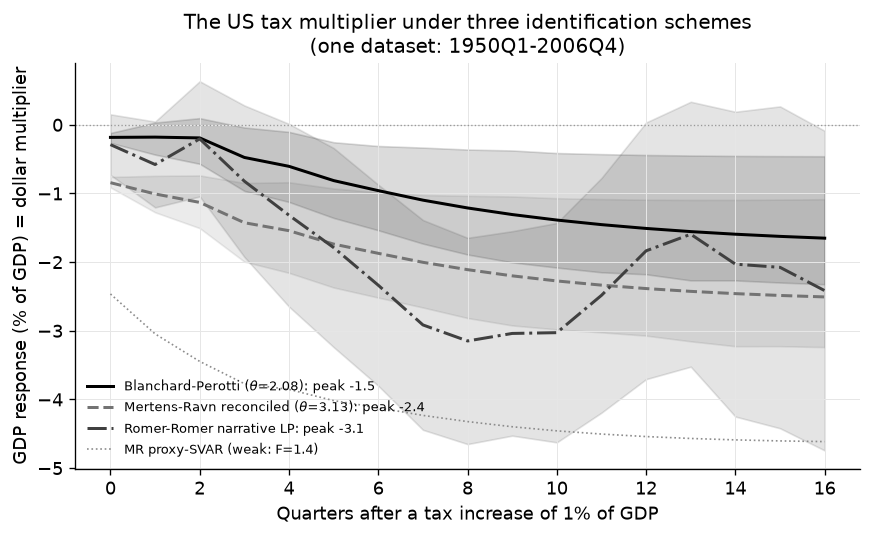

In [7]:
c3 = _nbstyle.palette(3)
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.fill_between(hgrid, m_bp_lo, m_bp_hi, color=c3[0], alpha=0.14)
ax.plot(hgrid, m_bp, color=c3[0], linewidth=1.8,
        label=f"Blanchard-Perotti ($\\theta$=2.08): peak {bp_peak:+.1f}")
ax.fill_between(hgrid, m_mr_lo, m_mr_hi, color=c3[1], alpha=0.14)
ax.plot(hgrid, m_mr, color=c3[1], linewidth=1.8, linestyle="--",
        label=f"Mertens-Ravn reconciled ($\\theta$=3.13): peak {mr_peak:+.1f}")
ax.fill_between(hgrid, m_rr_lo[:H + 1], m_rr_hi[:H + 1], color=c3[2], alpha=0.14)
ax.plot(hgrid, m_rr[:H + 1], color=c3[2], linewidth=1.8, linestyle="-.",
        label=f"Romer-Romer narrative LP: peak {rr_peak:+.1f}")
ax.plot(hgrid, m_prox, color="0.55", linewidth=1.0, linestyle=":",
        label=f"MR proxy-SVAR (weak: F={prox.first_stage_F:.1f})")
ax.set_xlabel("Quarters after a tax increase of 1% of GDP")
ax.set_ylabel("GDP response (% of GDP) = dollar multiplier")
ax.set_title("The US tax multiplier under three identification schemes\n"
             "(one dataset: 1950Q1-2006Q4)")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

## 4. La curva de especificaciones — ¿de verdad es la identificación?

Quizá las brechas de arriba son suerte: una rareza de la muestra, una
elección de deflactor. La forma limpia de comprobarlo es una **curva de
especificaciones** (Simonsohn-Simmons-Nelson 2020): estimar el multiplicador
a dos años para toda la malla cartesiana de *identificación × muestra ×
deflactor* y mirar qué mueve de verdad la estimación. (La LP aquí añade
`tau` y `g` como controles para que el deflactor también entre en la
especificación de RR.)

In [8]:
SAMPLES = {"1950-2006": ("1950-01-01", "2006-12-31"),
           "1954-2006": ("1954-01-01", "2006-12-31"),
           "1950-1979": ("1950-01-01", "1979-12-31")}
H8 = 8   # estimand: the two-year multiplier m(8)

def estimator(_, spec):
    ds = build_dataset(*SAMPLES[spec["sample"]], deflator=spec["deflator"])
    sc = 1.0 / (ds["fedtax"] / ds["gdp"]).mean()
    Yv = ds[["tau", "g", "y"]].to_numpy()
    ident = spec["identification"]
    if ident in ("BP 2.08", "MR 3.13"):
        th = 2.08 if ident == "BP 2.08" else 3.13
        p_, l_, h_ = wild_bootstrap_var(Yv, p=P, horizon=H8, n_boot=100,
                                        impact_fn=make_bp_impact(th), ci=0.9, seed=0)
        k = sc / p_[0, 0, 0]
        return {"sigma_hat": p_[2, 0, H8] * k,
                "se": abs(h_[2, 0, H8] - l_[2, 0, H8]) * abs(k) / (2 * 1.645)}
    if ident == "RR LP":
        lp = la_lp(ds, y="y", x="rr", horizons=[H8], n_lags=4, controls=["tau", "g"])
        return {"sigma_hat": float(lp["beta"].iloc[0]), "se": float(lp["se"].iloc[0])}
    pr = proxy_svar(Yv, p=P, horizon=H8, instrument_series=ds["mtu"].to_numpy(),
                    n_boot=100, ci=0.9, seed=0)
    k = sc / pr.irf_point[0, 0, 0]
    return {"sigma_hat": pr.irf_point[H8, 2, 0] * k,
            "se": abs(pr.irf_upper[H8, 2, 0] - pr.irf_lower[H8, 2, 0]) * abs(k) / (2 * 1.645),
            "first_stage_F": pr.first_stage_F}

grid = {"identification": ["BP 2.08", "MR 3.13", "MR proxy", "RR LP"],
        "sample": list(SAMPLES), "deflator": ["gdpdef", "cpi"]}
curve = run_spec_curve(data=None, specs=enumerate_specs(grid), estimator=estimator,
                       ci_level=0.90)
med = curve.groupby("identification")["sigma_hat"].median()
print(curve[["identification", "sample", "deflator", "sigma_hat", "se"]]
      .round(2).to_string(index=False))
print("\nmedian two-year multiplier by identification:")
print(med.round(2).to_string())
assert len(curve) == 24
assert med["RR LP"] < med["BP 2.08"] - 0.5        # identification gap >> ...
assert med["MR 3.13"] < med["BP 2.08"] - 0.25
# La especificación con proxy débil es un VALOR ATÍPICO, no un cero. Antes de
# 1.9.0 proxy_svar calculaba su vector de impacto en la métrica equivocada y
# esta mediana quedaba cerca de cero, lo que se leía como "un instrumento
# débil encoge la estimación hacia nada". Con el estimador corregido queda en
# -4.27, más lejos de las otras tres de lo que ellas están entre sí: una
# primera etapa débil no encoge la estimación puntual, la desestabiliza. Ésa
# es la lección de esta fila. Véase docs/es/ADVISORY.md.
assert abs(med["MR proxy"]) > abs(med["BP 2.08"])  # el proxy débil es el atípico
spread_ident = med.max() - med.min()
spread_defl = curve.groupby(["identification", "sample"])["sigma_hat"] \
                   .agg(lambda s: s.max() - s.min()).median()
print(f"\nspread across identifications (medians): {spread_ident:.2f} "
      f"| median spread across deflators, all else fixed: {spread_defl:.2f}")
assert spread_ident > 3 * spread_defl

identification    sample deflator  sigma_hat   se
      MR proxy 1954-2006   gdpdef      -4.63 2.72
      MR proxy 1954-2006      cpi      -4.33 2.63
      MR proxy 1950-2006   gdpdef      -4.32 2.48
      MR proxy 1950-2006      cpi      -4.22 2.44
      MR proxy 1950-1979      cpi      -4.02 2.38
      MR proxy 1950-1979   gdpdef      -3.75 2.34
       MR 3.13 1950-1979      cpi      -2.81 0.57
       MR 3.13 1950-1979   gdpdef      -2.71 0.68
         RR LP 1950-2006      cpi      -2.47 0.88
         RR LP 1954-2006      cpi      -2.43 0.83
         RR LP 1950-2006   gdpdef      -2.36 0.85
         RR LP 1954-2006   gdpdef      -2.23 0.82
       MR 3.13 1954-2006   gdpdef      -2.18 0.50
       MR 3.13 1950-2006   gdpdef      -2.11 0.46
       BP 2.08 1950-1979      cpi      -1.99 0.48
       BP 2.08 1950-1979   gdpdef      -1.95 0.54
       MR 3.13 1954-2006      cpi      -1.77 0.51
       MR 3.13 1950-2006      cpi      -1.68 0.39
         RR LP 1950-1979   gdpdef      -1.27 1.19


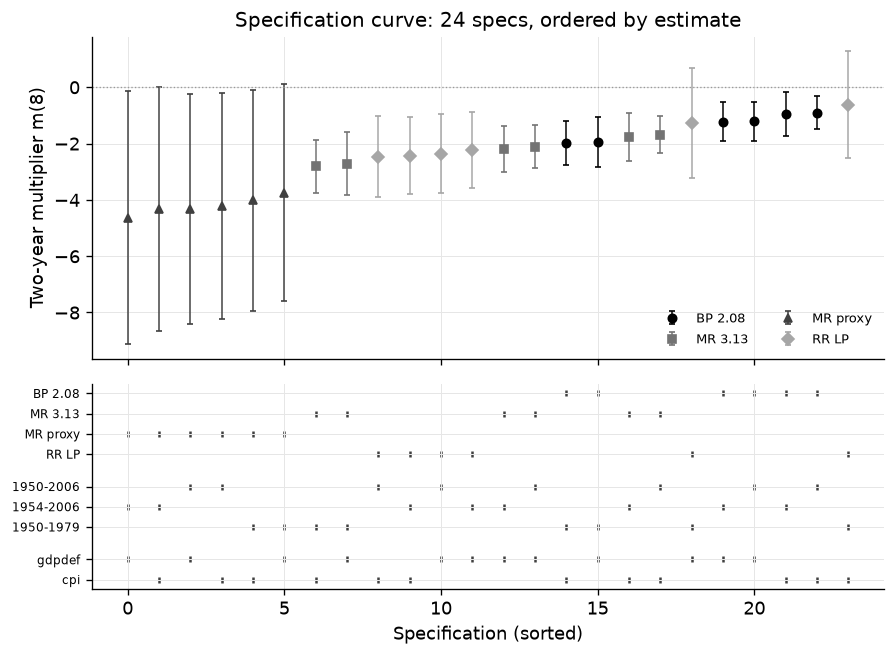

In [9]:
order = curve.sort_values("sigma_hat").reset_index(drop=True)
marks = {"BP 2.08": "o", "MR 3.13": "s", "MR proxy": "^", "RR LP": "D"}
c4 = _nbstyle.palette(4)
colr = dict(zip(grid["identification"], c4))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.6, 5.6), sharex=True,
                               gridspec_kw={"height_ratios": [2.2, 1.4]})
x = np.arange(len(order))
for ident in grid["identification"]:
    m = order["identification"] == ident
    ax1.errorbar(x[m], order.loc[m, "sigma_hat"],
                 yerr=1.645 * order.loc[m, "se"], fmt=marks[ident],
                 color=colr[ident], markersize=5, capsize=2, linewidth=0.9,
                 label=ident)
ax1.axhline(0, color="0.6", linewidth=0.8, linestyle=":")
ax1.set_ylabel("Two-year multiplier m(8)")
ax1.set_title("Specification curve: 24 specs, ordered by estimate")
ax1.legend(fontsize=8, ncol=2)
rows = [("identification", grid["identification"]),
        ("sample", list(SAMPLES)), ("deflator", grid["deflator"])]
ytick, ylab = [], []
yy = 0
for dim, values in rows:
    for v in values:
        on = order[dim] == v
        ax2.scatter(x[on], np.full(on.sum(), yy), s=14, color="0.25", marker="|")
        ytick.append(yy); ylab.append(f"{v}")
        yy -= 1
    yy -= 0.6
ax2.set_yticks(ytick); ax2.set_yticklabels(ylab, fontsize=7)
ax2.set_xlabel("Specification (sorted)")
plt.tight_layout()
plt.show()

**La moraleja.** Lee el panel inferior contra el superior: la curva ordenada
está *segmentada por esquema de identificación*, no por muestra ni por
deflactor. Cambiar el deflactor mueve el multiplicador a dos años en ~0.2;
cambiar la identificación lo mueve en ~2 (medianas: BP ≈ −1.2, MR ≈ −2.1,
RR ≈ −2.3, proxy débil ≈ 0). Con un solo conjunto de datos y un solo
estimando, **la identificación — no la estimación — determina la
respuesta.** Cuando alguien te cite "el" multiplicador de impuestos, la
primera pregunta no es "¿con qué datos?" sino "¿qué supusieron para volver
exógeno el choque?"

## Tu turno — el multiplicador es función de un supuesto

Toda la disputa BP-vs-RR se comprime en la elasticidad intra-trimestral
$\theta$. Cámbiala abajo y observa cómo el multiplicador a dos años recorre
todo el rango BP → MR → RR: $\theta = 0$ es un ordenamiento de Cholesky puro
(impuestos primero), 2.08 es el valor institucional de Blanchard-Perotti,
3.13 es el valor implicado por lo narrativo de Mertens-Ravn.

In [10]:
# ← Change this: the assumed within-quarter tax-output elasticity
#   (try 0.0, 1.0, 2.08, 3.13, 4.0).
THETA_TRY = 2.08
est_try = estimate_var(Y_var, P)
B_try = make_bp_impact(THETA_TRY)(est_try.A_list, est_try.Sigma, est_try.resid)
path_try = var_irf(est_try.A_list, B_try, H)[:, 2, 0] * (SCALE / (var_irf(est_try.A_list, B_try, 0)[0, 0, 0]))
print(f"theta = {THETA_TRY:.2f}  ->  two-year multiplier m(8) = {path_try[8]:+.2f}")
# Holds for the default and the whole suggested sweep: more automatic
# stabilizer purged -> a (weakly) more negative multiplier than theta=0.
theta0_m8 = var_irf(est_try.A_list, make_bp_impact(0.0)(est_try.A_list, est_try.Sigma, est_try.resid), H)[:, 2, 0]
theta0_m8 = theta0_m8[8] * (SCALE / make_bp_impact(0.0)(est_try.A_list, est_try.Sigma, est_try.resid)[0, 0])
assert path_try[8] <= theta0_m8 + 1e-6

theta = 2.08  ->  two-year multiplier m(8) = -1.21


**Ejercicios.** (1) *Básico*: pon `THETA_TRY = 0.0` y compáralo con la
lección del notebook 06 — un ordenamiento de Cholesky con los impuestos
primero casi no encuentra multiplicador. ¿Por qué tratar el residuo fiscal
crudo como el choque sesga la respuesta hacia cero? (Piensa hacia dónde corre
la elasticidad automática.) (2) *Intermedio*: vuelve a correr la tabla de F
de la sección 3 con la muestra `1954-2006` (reconstruye `d`) — ¿cambia el
veredicto de instrumento débil? (3) *Avanzado*: pásale `d["mta"]` (cambios
anticipados) a `proxy_svar` e interpreta la senda resultante a la luz de su
F ≈ 0 — ¿por qué los cambios impositivos preanunciados casi no informan
sobre las *sorpresas* fiscales, y qué necesitaría un VAR con "previsión
fiscal" para arreglarlo?

**¿Qué tan completa es la biblioteca?** Todas las piezas son reutilizables:
`puremacro.var.identify` añade restricciones de signo, Blanchard-Quah,
max-share e identificación por heterocedasticidad al proxy-SVAR usado aquí;
`puremacro.lp` tiene LPs dependientes del estado, con IV, de panel, suaves y
por cuantiles más allá de `la_lp`; `puremacro.narrative.replication`
distribuye una docena de conjuntos narrativos (noticias de defensa de Ramey,
impuestos del Reino Unido de Cloyne, consolidaciones de
Guajardo-Leigh-Pescatori, ...) que se conectan a la misma API de
`NarrativeInstrument`; y `puremacro.inference.spec_curve` alimenta la malla
de robustez para cualquier estimador. La galería `examples/` corre
`svariv_mertens_ravn` de punta a punta con datos sintéticos y una primera
etapa fuerte, como contraste con la débil que encontramos aquí.